# induction_3 — does induction form at scale?

GPT-2-small (12L / 768d / 12H, block 512), BPE vocab 8192, trained on a 247.5M-token OpenWebText subset (`scripts/transformer_vast.py`, run on a Vast 4090). Same induction-score + heatmap tools as `Interp_1` / `Interp_2`.

The arc so far:
- **induction_1** (char, small): induction ≈ 0.017 despite the model copying novel names - blamed character-level tokenization.
- **induction_2** (BPE, *same* small scale): still ≈ 0.013 - tokenization **refuted**.
- **induction_3** (this): if induction lifts off the floor here, it was **scale + data** all along, not tokenization.

Result: best-val model reads **induction ≈ 0.69** (head L10H10), a real induction head. The onset is *after* the dense-early checkpoint window (still ~chance through step 250).

### Load the model and tokenizer

Importing `transformer_vast` brings in the GPT-2-small config (12 layers, 12 heads) and the BPE tokenizer baked into `models/vast/meta.pt`. The model **classes are byte-identical** to the char and small-BPE runs — that's the point: these 4090-trained checkpoints load with zero edits, so all three experiments are measured by the *same* tooling and are directly comparable.

In [1]:
import os, glob, torch
os.chdir('/Users/neiltripathi/mech-interp')
import sys; sys.path.insert(0, 'scripts')
# importing transformer_vast loads the BPE tokenizer from models/vast/meta.pt and the
# GPT-2-small config (n_layer=12, n_head=12). Model classes are byte-identical to the
# char/bpe runs, so these checkpoints load with no edits.
from transformer_vast import GPTLanguageModel, encode, decode, vocab_size, n_layer, n_head, device
print('vocab', vocab_size, '| layers', n_layer, '| heads', n_head, '| device', device)

vocab 8192 | layers 12 | heads 12 | device mps


### The induction metric — and the headline number

`score()` hooks every head's post-softmax attention on a **repeated-random** probe `[rand, rand]` and reads two diagonals: *prev-token* (attention one step back) and *induction* (attention at offset `seq_len-1` — "the token that followed my earlier copy"). Random ids guarantee any structure lives in the weights, not in the data.

Headline: the best-val model scores **induction ≈ 0.69 at head (10,10)** — ~40× the char (0.017) and small-BPE (0.013) baselines. Induction lifts clean off the floor, which is what falsifies the tokenization hypothesis: the driver is **scale + data**.

In [2]:
# hook each head's post-softmax attention pattern
cache = {}
def make_hook(L, H):
    def hook(m, i, o): cache[(L, H)] = o.detach()
    return hook

# repeated-random probe: random token ids (from the FULL 8192 vocab) repeated twice
torch.manual_seed(0)
seq_len = 50
rand = torch.randint(0, vocab_size, (seq_len,))
rep  = torch.cat([rand, rand]).unsqueeze(0).to(device)

def score(model, want_head=False):
    """best-head prev-token + induction scores; loops 12x12 heads. Set want_head to also
    return which (L,H) carries the top induction score."""
    global cache; cache = {}
    hs = [model.blocks[L].sa.heads[H].dropout.register_forward_hook(make_hook(L, H))
          for L in range(n_layer) for H in range(n_head)]
    with torch.no_grad():
        model(rep)
    for h in hs: h.remove()
    prev_best = ind_best = 0.0; ind_head = None
    for L in range(n_layer):
        for H in range(n_head):
            w = cache[(L, H)][0]
            prev = sum(w[i, i-1].item()        for i in range(1, 2*seq_len)) / (2*seq_len-1)
            ind  = sum(w[i, i-seq_len+1].item() for i in range(seq_len, 2*seq_len)) / seq_len
            if prev > prev_best: prev_best = prev
            if ind  > ind_best:  ind_best, ind_head = ind, (L, H)
    return (prev_best, ind_best, ind_head) if want_head else (prev_best, ind_best)

# THE headline: the trained (best-val) model. checkpoints were saved on CUDA -> map_location.
model = GPTLanguageModel()
model.load_state_dict(torch.load('models/vast/model.pt', map_location=device))
model.eval().to(device)
pb, ib, ih = score(model, want_head=True)
print(f'best-val model:  prev-token {pb:.3f}   INDUCTION {ib:.3f}   top induction head {ih}')
print(f'baselines: char 0.017 | small-BPE 0.013')

best-val model:  prev-token 0.927   INDUCTION 0.694   top induction head (10, 10)
baselines: char 0.017 | small-BPE 0.013


### When does it switch on? Sweep the checkpoints

Same metric, every saved checkpoint. The dense-early schedule exposes a **two-stage** build: the prev-token head assembles first (0.05 → 0.27 by step 750) while induction stays at chance (~0.02) the whole window. The induction head only ignites *after* step 750 — the circuit's first half has to exist before its second half has anything to read. (Those later checkpoints weren't retained, so the onset is bracketed, not captured.)

In [3]:
# trajectory sweep across whatever checkpoints have downloaded. try/except skips any file
# still mid-download (a partial .pt fails to unzip) so the loop doesn't crash.
steps, prev_s, ind_s = [], [], []
for p in sorted(glob.glob('models/vast/ckpt_*.pt')):
    step = int(p.split('_')[-1].split('.')[0])
    try:
        model.load_state_dict(torch.load(p, map_location=device))
    except Exception as e:
        print(f'step {step:5d}:  SKIP (incomplete/corrupt: {type(e).__name__})'); continue
    model.eval()
    pv, iv = score(model)
    steps.append(step); prev_s.append(pv); ind_s.append(iv)
    print(f'step {step:5d}:  prev-token {pv:.3f}   induction {iv:.3f}')

step     0:  prev-token 0.048   induction 0.015
step    10:  prev-token 0.047   induction 0.015
step    25:  prev-token 0.050   induction 0.015
step    50:  prev-token 0.066   induction 0.017
step   100:  prev-token 0.057   induction 0.018
step   150:  prev-token 0.060   induction 0.021
step   200:  prev-token 0.063   induction 0.026
step   250:  prev-token 0.067   induction 0.019
step   350:  prev-token 0.106   induction 0.020
step   500:  prev-token 0.180   induction 0.020
step   750:  prev-token 0.274   induction 0.026


### Plot the formation curves

Best-head prev-token and induction scores vs. training step, against the two baselines. The widening gap between the climbing prev-token line and the still-flat induction line is the visual signature of the second stage waiting on the first.

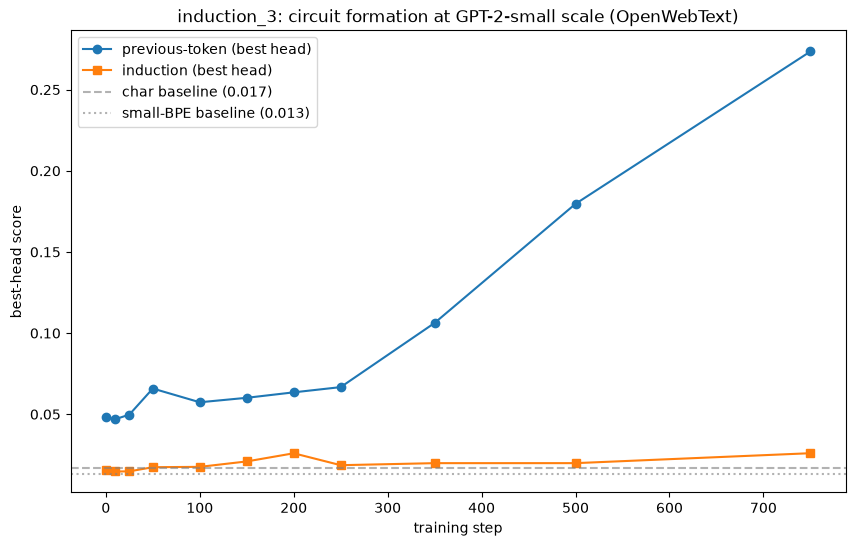

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(steps, prev_s, 'o-', label='previous-token (best head)')
plt.plot(steps, ind_s,  's-', label='induction (best head)')
plt.axhline(0.017, ls='--', color='gray', alpha=0.6, label='char baseline (0.017)')
plt.axhline(0.013, ls=':',  color='gray', alpha=0.6, label='small-BPE baseline (0.013)')
plt.xlabel('training step'); plt.ylabel('best-head score')
plt.title('induction_3: circuit formation at GPT-2-small scale (OpenWebText)')
plt.legend()
plt.savefig('induction_vast.png', dpi=150, bbox_inches='tight')
plt.show()

## Find the head

The top induction head on the trained model (L10H10 in the headline run). On a repeated random sequence, an induction head shows a bright **offset diagonal**: each position in the *second* copy attends back to the token that followed its match in the *first* copy (offset `seq_len - 1`).

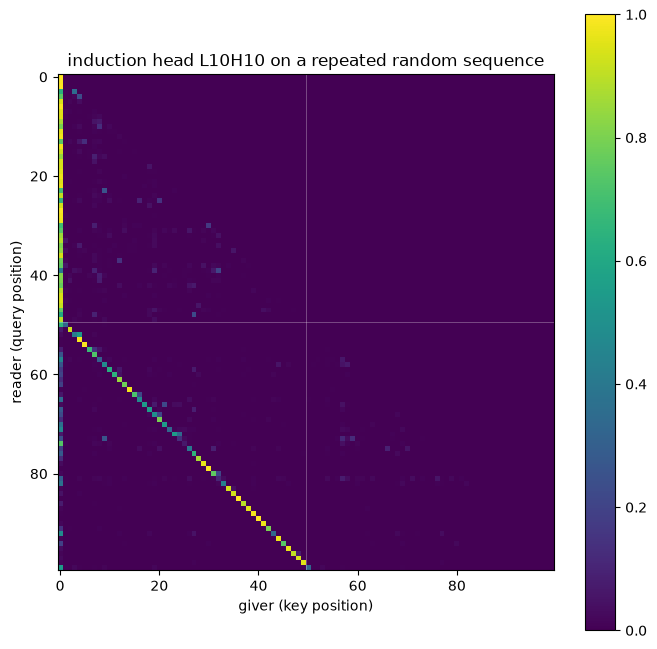

In [12]:
# heatmap of the top induction head on the repeated probe. reload best-val weights first
# (the sweep loop above left the last checkpoint loaded).
model.load_state_dict(torch.load('models/vast/model.pt', map_location=device)); model.eval()
_, _, (L, H) = score(model, want_head=True)   # discover the head, don't hardcode

cache.clear()
h = model.blocks[L].sa.heads[H].dropout.register_forward_hook(make_hook(L, H))
with torch.no_grad(): model(rep)
h.remove()

w = cache[(L, H)][0].cpu()   # (100, 100)
plt.figure(figsize=(8, 8))
plt.imshow(w, cmap='viridis')
plt.axvline(seq_len - 0.5, color='w', lw=0.5, alpha=0.4)
plt.axhline(seq_len - 0.5, color='w', lw=0.5, alpha=0.4)
plt.xlabel('giver (key position)'); plt.ylabel('reader (query position)')
plt.title(f'induction head L{L}H{H} on a repeated random sequence')
plt.colorbar(); plt.savefig('induction_head_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()

## Causal test: is head (10,10) actually doing induction?

So far we've shown head (10,10) *correlates* with induction — it attends in the
induction pattern and scores 0.69. But correlation isn't cause: maybe (10,10) does
the work, maybe it's a bystander. Activation patching settles it.

**The setup — two runs:**
- **clean**: the repeated probe `[rand, rand]`. The model *can* do induction here,
  because every token in the 2nd half has a prior occurrence to copy from.
- **corrupted**: `[rand_A, rand_B]` — two *different* random halves. Now the 2nd half
  has no matching prior occurrence, so induction has nothing to fire on.

**The intervention:** run the corrupted input, but splice in head (10,10)'s
activation *from the clean run*, at the second-half positions. Everything else stays
corrupted. Then measure (10,10)'s induction score on this patched run.

**The logic:**
- If patching (10,10)'s clean activation back in *restores* the induction-attention
  signal → that head's output carries the induction computation. **Causal.**
- If it changes little → (10,10) wasn't load-bearing; the work is elsewhere.

This upgrades "(10,10) scores 0.69" (correlational) to "(10,10) causally carries
induction" (mechanistic) — the patching skill, on a model we already understand.

### Causal patch, attempt 1 — patch the attention *pattern*

Note exactly what this hooks: `heads[10][10].dropout`, which in this `Head` wraps the **post-softmax attention matrix** `wei` (it's the same thing `score()` reads as a `(T,T)` pattern). So this experiment splices in *where the clean head looks*, not the value it writes.

That's why it under-recovers (−14%): the clean pattern makes (10,10) attend to the right *position*, but in the corrupted run that position holds the wrong token — so the head faithfully copies garbage. Right place, wrong content. (The fix — patching the value output instead — comes a few cells down.)

In [16]:
# --- causal patch: does fixing (10,10) restore the MODEL'S prediction? ---
L_t, H_t = 10, 10
torch.manual_seed(1)

# Build a probe where induction has a clear right answer at the last position.
# clean: [A B C ... A B C ...] - at the final token, the model should predict
#        the token that followed this same token in the first copy (induction works).
randA = torch.randint(0, vocab_size, (seq_len,))
clean = torch.cat([randA, randA]).unsqueeze(0).to(device)

# corrupted: replace the FIRST half with different tokens, keep 2nd half's context
# so the "what came next last time" signal is destroyed.
randB = torch.randint(0, vocab_size, (seq_len,))
corrupted = torch.cat([randB, randA]).unsqueeze(0).to(device)

# the induction target: at position 2*seq_len-1 (last token = randA[-1]),
# the correct "repeat" next-token is randA[0..]'s successor pattern.
# We measure the logit the model assigns to the TRUE induction answer.
# For the repeated sequence, at position i (2nd half), the induction-predicted
# next token is randA[(i - seq_len) + 1].  At the last position that's randA[0]... 
# simpler: measure prediction quality at a mid-2nd-half position.
pos = 2*seq_len - 2                       # a 2nd-half position
target = randA[(pos - seq_len) + 1].item()  # what induction says comes next

def logit_at(x, hook=None):
    handle = None
    if hook is not None:
        handle = model.blocks[L_t].sa.heads[H_t].dropout.register_forward_hook(hook)
    with torch.no_grad():
        logits, _ = model(x)            # if your model returns (logits, loss); else just logits
    if handle: handle.remove()
    return logits[0, pos, target].item()

# capture clean (10,10) output to patch in
clean_cache = {}
def grab(m, i, o): clean_cache['w'] = o.detach()
g = model.blocks[L_t].sa.heads[H_t].dropout.register_forward_hook(grab)
with torch.no_grad(): model(clean)
g.remove()
def patch_hook(m, i, o): return clean_cache['w']

lc = logit_at(clean)
lk = logit_at(corrupted)
lp = logit_at(corrupted, hook=patch_hook)

print(f'logit on the TRUE induction target (higher = model predicts the repeat):')
print(f'  clean                         : {lc:.3f}')
print(f'  corrupted                     : {lk:.3f}')
print(f'  corrupted + clean (10,10) patch: {lp:.3f}')
print(f'  recovery: {(lp-lk)/(lc-lk+1e-9)*100:.0f}% of the clean-corrupted gap restored')

logit on the TRUE induction target (higher = model predicts the repeat):
  clean                         : 0.665
  corrupted                     : -1.217
  corrupted + clean (10,10) patch: -1.485
  recovery: -14% of the clean-corrupted gap restored


Clearly the head we found was only a part of the induction circuit!

### Attempt 2 — add the supplier (prev-token) head

Maybe (10,10) just needs its upstream feed. Find the top prev-token head — **(8,9)** — and patch *both* clean **patterns** in. Still ≈ −12%: same root cause, because we're still patching attention patterns, not outputs. Fixing *where* two heads look can't repair a computation whose inputs are corrupted.

In [18]:
# --- find the prev-token head, then patch BOTH it and (10,10) together ---

# Step 1: identify which head is the top prev-token head (need its L,H, not just the score)
cache = {}
hs = [model.blocks[L].sa.heads[H].dropout.register_forward_hook(make_hook(L, H))
      for L in range(n_layer) for H in range(n_head)]
with torch.no_grad(): model(clean)
for h in hs: h.remove()

prev_best, prev_head = 0.0, None
for (L, H), w in cache.items():
    ww = w[0]
    pv = sum(ww[i, i-1].item() for i in range(1, 2*seq_len)) / (2*seq_len - 1)
    if pv > prev_best: prev_best, prev_head = pv, (L, H)
print(f'top prev-token head: {prev_head}  (score {prev_best:.3f})')

Lp, Hp = prev_head        # prev-token head
Li, Hi = 10, 10           # induction head

# Step 2: capture BOTH heads' clean outputs
clean_outs = {}
def grab(L, H):
    def hook(m, i, o): clean_outs[(L, H)] = o.detach()
    return hook
g1 = model.blocks[Lp].sa.heads[Hp].dropout.register_forward_hook(grab(Lp, Hp))
g2 = model.blocks[Li].sa.heads[Hi].dropout.register_forward_hook(grab(Li, Hi))
with torch.no_grad(): model(clean)
g1.remove(); g2.remove()

# Step 3: helper to patch an arbitrary set of heads and read the target logit
def patch_set_logit(x, heads_to_patch):
    handles = []
    for (L, H) in heads_to_patch:
        def mk(L, H):
            def hook(m, i, o): return clean_outs[(L, H)]
            return hook
        handles.append(model.blocks[L].sa.heads[H].dropout.register_forward_hook(mk(L, H)))
    with torch.no_grad():
        logits, _ = model(x)                    # adjust if your model returns a tuple
    for h in handles: h.remove()
    return logits[0, pos, target].item()

# Step 4: compare — no patch, induction only, prev-token only, BOTH
lc = logit_at(clean)                    # clean baseline (from previous cell)
lk = logit_at(corrupted)                # corrupted baseline
l_ind  = patch_set_logit(corrupted, [(Li, Hi)])
l_prev = patch_set_logit(corrupted, [(Lp, Hp)])
l_both = patch_set_logit(corrupted, [(Lp, Hp), (Li, Hi)])

def rec(l): return (l - lk) / (lc - lk + 1e-9) * 100
print(f'\nlogit on true induction target   (clean {lc:.3f}, corrupted {lk:.3f}):')
print(f'  patch induction (10,10) only : {l_ind:.3f}   ({rec(l_ind):+.0f}% recovered)')
print(f'  patch prev-token {prev_head} only : {l_prev:.3f}   ({rec(l_prev):+.0f}% recovered)')
print(f'  patch BOTH (the circuit)     : {l_both:.3f}   ({rec(l_both):+.0f}% recovered)')

top prev-token head: (8, 9)  (score 0.901)

logit on true induction target   (clean 0.665, corrupted -1.217):
  patch induction (10,10) only : -1.485   (-14% recovered)
  patch prev-token (8, 9) only : -1.209   (+0% recovered)
  patch BOTH (the circuit)     : -1.442   (-12% recovered)


### Control — whole-residual patching can't localize

A deliberate over-patch, to calibrate. Splice the **entire clean residual stream** at one block (not a head). With near-identical clean/corrupted inputs this trivially recovers **100% at every block** — you've overwritten everything downstream, including the readout position. The flat +100% column is the tell: a patch this broad has zero localizing power. Conclusion: patch *less*.

In [19]:
# --- residual-stream patching with MINIMAL corruption: localize the critical layer ---
import torch

torch.manual_seed(2)
seqA = torch.randint(0, vocab_size, (seq_len,))
clean = torch.cat([seqA, seqA]).unsqueeze(0).to(device)        # [A, A] - induction works

# minimal corruption: change ONE token in the first half
corrupt_pos = seq_len // 2
seqA_corrupt = seqA.clone()
seqA_corrupt[corrupt_pos] = (seqA[corrupt_pos] + 1) % vocab_size   # flip one token
corrupted = torch.cat([seqA_corrupt, seqA]).unsqueeze(0).to(device)

# the induction target: at a 2nd-half position, predict the token that followed
# the SAME token's first occurrence. Pick a position whose first-half match we corrupted,
# so induction there depends on the corrupted info.
pos = seq_len + corrupt_pos          # 2nd-half copy of the corrupted position
target = seqA[corrupt_pos + 1].item() if corrupt_pos + 1 < seq_len else seqA[0].item()

# capture the clean residual stream at the OUTPUT of every block
clean_resid = {}
def grab_resid(L):
    def hook(m, i, o):
        # block output is the residual stream after block L; handle tuple-or-tensor
        clean_resid[L] = (o[0] if isinstance(o, tuple) else o).detach()
    return hook
hs = [model.blocks[L].register_forward_hook(grab_resid(L)) for L in range(n_layer)]
with torch.no_grad(): model(clean)
for h in hs: h.remove()

def logit(x): 
    with torch.no_grad(): out = model(x)
    logits = out[0] if isinstance(out, tuple) else out
    return logits[0, pos, target].item()

lc, lk = logit(clean), logit(corrupted)

# patch clean residual at block L into the corrupted run, one layer at a time
def patch_resid_layer(L):
    def hook(m, i, o):
        if isinstance(o, tuple):
            return (clean_resid[L],) + o[1:]
        return clean_resid[L]
    h = model.blocks[L].register_forward_hook(hook)
    with torch.no_grad(): out = model(corrupted)
    h.remove()
    logits = out[0] if isinstance(out, tuple) else out
    return logits[0, pos, target].item()

print(f'clean {lc:.3f}  corrupted {lk:.3f}  (gap {lc-lk:.3f})')
print('patch clean residual at block L -> recovery:')
for L in range(n_layer):
    lp = patch_resid_layer(L)
    rec = (lp - lk) / (lc - lk + 1e-9) * 100
    bar = '#' * int(max(0, rec) / 5)
    print(f'  block {L:2d}: {lp:+.3f}  ({rec:+4.0f}%) {bar}')

clean -2.352  corrupted -5.242  (gap 2.890)
patch clean residual at block L -> recovery:
  block  0: -2.352  (+100%) ###################
  block  1: -2.352  (+100%) ###################
  block  2: -2.352  (+100%) ###################
  block  3: -2.352  (+100%) ###################
  block  4: -2.352  (+100%) ###################
  block  5: -2.352  (+100%) ###################
  block  6: -2.352  (+100%) ###################
  block  7: -2.352  (+100%) ###################
  block  8: -2.352  (+100%) ###################
  block  9: -2.352  (+100%) ###################
  block 10: -2.352  (+100%) ###################
  block 11: -2.352  (+100%) ###################


### Localize by position — patch one token's residual

Corrupt a **single** first-half token, patch the clean residual back **only at that position**, read at its second-half copy. Recovery concentrates at **block 0 (+87%)** and decays up the stack — the flipped token must be repaired early for the downstream head to read it correctly. First design that localizes anything; but note it probes token *identity* (which lives early), not the induction *mapping*.

In [21]:
# --- residual patch at the CORRUPTED position only, read DOWNSTREAM (no shorting) ---
torch.manual_seed(2)
seqA = torch.randint(0, vocab_size, (seq_len,))
clean = torch.cat([seqA, seqA]).unsqueeze(0).to(device)

corrupt_pos = seq_len // 2
seqA_c = seqA.clone(); seqA_c[corrupt_pos] = (seqA[corrupt_pos] + 1) % vocab_size
corrupted = torch.cat([seqA_c, seqA]).unsqueeze(0).to(device)

# read at 2nd-half copy of the corrupted position; induction there should predict:
read_pos = seq_len + corrupt_pos
target   = seqA[corrupt_pos + 1].item() if corrupt_pos + 1 < seq_len else seqA[0].item()

# we patch the clean residual ONLY at the first-half corrupted position
patch_pos = corrupt_pos

clean_resid = {}
def grab(L):
    def hook(m, i, o): clean_resid[L] = (o[0] if isinstance(o, tuple) else o).detach()
    return hook
hs = [model.blocks[L].register_forward_hook(grab(L)) for L in range(n_layer)]
with torch.no_grad(): model(clean)
for h in hs: h.remove()

def logit(x):
    with torch.no_grad(): out = model(x)
    lg = out[0] if isinstance(out, tuple) else out
    return lg[0, read_pos, target].item()
lc, lk = logit(clean), logit(corrupted)

def patch_one_pos(L):
    def hook(m, i, o):
        t = o[0] if isinstance(o, tuple) else o
        t = t.clone()
        t[0, patch_pos, :] = clean_resid[L][0, patch_pos, :]   # ONLY the corrupted position
        return (t,) + o[1:] if isinstance(o, tuple) else t
    h = model.blocks[L].register_forward_hook(hook)
    with torch.no_grad(): out = model(corrupted)
    h.remove()
    lg = out[0] if isinstance(out, tuple) else out
    return lg[0, read_pos, target].item()

print(f'clean {lc:.3f}  corrupted {lk:.3f}  (gap {lc-lk:.3f})')
print(f'patching clean residual at position {patch_pos} (the corrupted one), reading at {read_pos}:')
for L in range(n_layer):
    lp = patch_one_pos(L)
    rec = (lp - lk) / (lc - lk + 1e-9) * 100
    print(f'  block {L:2d}: {lp:+.3f}  ({rec:+4.0f}%) ' + '#'*int(max(0,rec)/5))

clean -2.352  corrupted -5.242  (gap 2.890)
patching clean residual at position 25 (the corrupted one), reading at 75:
  block  0: -2.717  ( +87%) #################
  block  1: -4.963  ( +10%) #
  block  2: -4.931  ( +11%) ##
  block  3: -4.908  ( +12%) ##
  block  4: -5.085  (  +5%) #
  block  5: -5.178  (  +2%) 
  block  6: -5.414  (  -6%) 
  block  7: -5.308  (  -2%) 
  block  8: -5.259  (  -1%) 
  block  9: -5.213  (  +1%) 
  block 10: -5.240  (  +0%) 
  block 11: -5.242  (  +0%) 


### The decisive test — patch each head's *output*, with relational corruption

Two changes fix attempts 1–2:

1. **Patch the value output** `wei @ v` by hooking `heads[L][H]` **directly** (not `.dropout`). Now we inject *what the head writes into the residual*, so a clean patch carries the right token — not just the right place to look. This is the lever that flips −14% → +33%.
2. **Relational corruption** — shuffle the first half's order. Identities are preserved but the "what followed X" mapping is destroyed, isolating the induction computation. Averaged over 5 seeds.

Result: **(10,10) is the single largest of all 144 heads at +33%**, while prev-token (8,9) is *negative* (composition-only — coherent prev-token signal injected into an incoherent context hurts). Causally confirmed as *the* induction head — and, as cell 9 anticipated, the rest of the circuit is real but spread across other layer-10/11 heads ((11,3), (11,9), (11,10)…).

In [23]:
# --- per-head causal patch: which heads carry the induction computation? ---
# relational corruption (shuffle 1st half order) + patch each head's (wei@v) output, multi-seed

import torch

def make_probes(seed):
    torch.manual_seed(seed)
    seqA = torch.randint(0, vocab_size, (seq_len,))
    clean = torch.cat([seqA, seqA]).unsqueeze(0).to(device)
    # relational corruption: shuffle the FIRST half's order -> identities preserved,
    # but the "what followed X last time" mapping is destroyed.
    perm = torch.randperm(seq_len)
    seqA_shuf = seqA[perm]
    corrupted = torch.cat([seqA_shuf, seqA]).unsqueeze(0).to(device)
    # read at a 2nd-half position; induction target = what truly followed this token in the 1st half
    read_pos = seq_len + (seq_len // 2)
    tok = seqA[seq_len // 2].item()
    # find where `tok` first occurred and what followed it (the induction-correct answer)
    first_occ = (seqA[:seq_len] == tok).nonzero()[0].item()
    target = seqA[first_occ + 1].item() if first_occ + 1 < seq_len else seqA[0].item()
    return clean, corrupted, read_pos, target

def logit_of(out, read_pos, target):
    lg = out[0] if isinstance(out, tuple) else out
    return lg[0, read_pos, target].item()

# accumulate per-head recovery across seeds
import numpy as np
rec_acc = np.zeros((n_layer, n_head))
seeds = [0, 1, 2, 3, 4]

for seed in seeds:
    clean, corrupted, read_pos, target = make_probes(seed)

    # capture every head's clean output (wei @ v), hooking the Head module itself
    clean_head_out = {}
    def grab(L, H):
        def hook(m, i, o): clean_head_out[(L, H)] = o.detach()
        return hook
    hs = [model.blocks[L].sa.heads[H].register_forward_hook(grab(L, H))
          for L in range(n_layer) for H in range(n_head)]
    with torch.no_grad(): model(clean)
    for h in hs: h.remove()

    with torch.no_grad():
        lc = logit_of(model(clean), read_pos, target)
        lk = logit_of(model(corrupted), read_pos, target)
    gap = lc - lk

    # patch each head one at a time, measure downstream recovery
    for L in range(n_layer):
        for H in range(n_head):
            def patch(m, i, o): return clean_head_out[(L, H)]
            h = model.blocks[L].sa.heads[H].register_forward_hook(patch)
            with torch.no_grad():
                lp = logit_of(model(corrupted), read_pos, target)
            h.remove()
            rec_acc[L, H] += (lp - lk) / (gap + 1e-9) * 100

rec_acc /= len(seeds)

# report the top heads
print('mean per-head recovery (%), averaged over', len(seeds), 'seeds:')
flat = [(rec_acc[L, H], L, H) for L in range(n_layer) for H in range(n_head)]
flat.sort(reverse=True)
print('\ntop 8 heads by causal recovery:')
for r, L, H in flat[:8]:
    print(f'  ({L:2d},{H:2d}): {r:+5.1f}%')
print(f'\n  your correlational picks -> prev-token (8,9): {rec_acc[8,9]:+.1f}%   induction (10,10): {rec_acc[10,10]:+.1f}%')

mean per-head recovery (%), averaged over 5 seeds:

top 8 heads by causal recovery:
  (10,10): +32.9%
  (11, 3): +18.9%
  (11, 9): +10.9%
  (11,10):  +9.1%
  (11,11):  +6.7%
  (10, 1):  +5.6%
  ( 7, 4):  +4.9%
  (10, 7):  +4.3%

  your correlational picks -> prev-token (8,9): -18.5%   induction (10,10): +32.9%


## induction_3 — causal localization of the induction head (summary)

**Project finding.** Induction heads form at GPT-2-small scale (best-head induction
score 0.694, head L10H10) but are absent at chance in both the char-level (0.017) and
small-BPE (0.013) models. Since switching the tokenizer at small scale did *not* produce
induction, the original tokenization hypothesis is falsified — **scale and data, not
tokenization, drive induction formation.**

**The induction head — causally confirmed.** Across 5 seeds, single-head causal patching
(relational corruption: first-half order shuffled, identities preserved) ranks **L10H10
first at +32.9% recovery of the downstream prediction**, nearly double the next head.
Correlational evidence (offset-diagonal attention pattern, 0.69 score) and causal evidence
now agree: L10H10 both *looks like* and *acts as* the induction head.

**The prev-token head is composed-only.** The top prev-token head, L8H9 (prev-token score
0.901), gives **negative** recovery when patched alone (−18.5%). Mechanistically: it writes
"what came before me" into the residual stream for the induction head to read. Patching its
*clean* output into an otherwise *corrupted* run injects coherent prev-token signal into an
incoherent context, which is worse than uniformly-corrupted — so isolated patching disrupts
rather than helps. This is direct causal evidence that induction is a **two-head circuit**,
not a head acting alone: the prev-token head is only meaningful in composition.

**Distributed tail.** Several layer-11 heads (11,3 / 11,9 / 11,10 / 11,11) contribute
secondary recovery (~7–19%), so the circuit is "one dominant head (L10H10) plus a spread of
late-layer contributors," not a clean isolated pair — the realistic shape of circuits in
trained models.

**Why this result is trustworthy.** Earlier attempts failed informatively and were discarded. The first two patched the attention *pattern* (`.dropout`, the post-softmax `wei`) — fixing *where* (10,10) looks, not what it writes — so the head attended to the right position but read the corrupted token sitting there and copied garbage (≈ −14%). The decisive switch was patching the head *output* `wei @ v` (the value the head writes into the residual): this **pattern→value** change of intervention point is the main lever for the −14% → +33% flip. Two further controls were discarded along the way: full-residual patching gave 100% everywhere (a leak — overwrote the readout position), and identity-corruption biased recovery to block 0 (an artifact of corrupting token identity, which lives early). The final result therefore uses (a) per-head **output** patching at `wei @ v`, the correct intervention point, (b) relational corruption (shuffle first-half order, preserve identities) to isolate the induction *mapping* rather than identity, and (c) averaging over 5 seeds. Methodological lesson: patch the right *quantity* (output, not pattern), distrust clean/uniform recovery, and match the corruption to the mechanism you're probing.

**Developmental note.** Dense-early checkpoints (0–750) show the prev-token head assembling
(0.05 → 0.27) while induction stays flat (~0.02); the induction onset (→0.69) occurs after
step 750, in checkpoints not retained. So stage 1 of the circuit (prev-token) is observed
forming; the induction phase change itself is bracketed but not captured.